# VAE Math Foundations

This companion notebook explains the math ideas behind `notebooks/05_vae.ipynb`. It is not a second VAE training notebook. The goal is to understand why the VAE code uses reconstruction loss, KL loss, `mu`, `logvar`, and the reparameterization trick.

## Learning purpose

Learn how VAE probability ideas make a latent space sampleable and how those ideas become the loss terms used in PyTorch code.

## Reference path

This notebook is designed to sit beside the practical notebook:

```text
notebooks/05_vae.ipynb
```

We will move slowly from ordinary autoencoders to the VAE loss function, then map the math back to the existing `loss_function()` implementation.


## 1. Ordinary autoencoder math

A regular autoencoder has two learned parts: an **encoder** and a **decoder**. The encoder compresses an input image into a smaller hidden representation. The decoder tries to rebuild the original image from that hidden representation.

```text
image x → encoder f(x) → latent code z → decoder g(z) → reconstruction x_hat
```

Simple formula view:

$$
z = f_\phi(x)
$$

$$
\hat{x} = g_\theta(z)
$$

Read this as: the encoder function $f_\phi$ turns the image $x$ into a latent code $z$, and the decoder function $g_\theta$ turns $z$ back into a reconstruction $\hat{x}$. The symbols $\phi$ and $\theta$ just mean the learned weights of the encoder and decoder.

Why use $\phi$ and $\theta$? They remind us that the functions are learned, not fixed. In this notebook, $\phi$ means the encoder parameters, which correspond to layers such as `fc1`, `fc21`, and `fc22`. The symbol $\theta$ means the decoder parameters, which correspond to layers such as `fc3` and `fc4`. Writing $f(x)$ and $g(z)$ is fine for intuition; writing $f_\phi(x)$ and $g_\theta(z)$ makes the trainable weights visible in the notation.

Meaning of the symbols:

- `x` is the original input image, such as one MNIST digit.
- `f(x)` is the encoder's output.
- `z` is the **latent code**, a smaller learned summary of the image.
- `g(z)` is the decoder's output.
- `x_hat` or $\hat{x}$ is the reconstructed version of the original image.

The important constraint is the **bottleneck**. The bottleneck is the smaller middle space where the model has fewer numbers than the original image. For MNIST, an input image has `28 × 28 = 784` pixel values. If the latent code has only 20 numbers, the model cannot simply store every pixel.

That pressure is useful. To reconstruct the image from fewer numbers, the model has to learn patterns that help rebuild many similar images, such as digit shape, stroke angle, loop size, and thickness. This is why autoencoders can be useful for compression, denoising, anomaly detection, and feature extraction.


### Reconstruction objective

A basic autoencoder trains by making the reconstruction `x_hat` close to the original input `x`.

```text
reconstruction loss = difference between x and x_hat
```

Simple formula view:

$$
\mathcal{L}_{\text{recon}} = d(x, \hat{x})
$$

Read this as: reconstruction loss is some distance or penalty $d$ between the original image $x$ and the rebuilt image $\hat{x}$. If the rebuilt image looks like the input image, the reconstruction loss is small. If the rebuilt image misses important pixels or changes the digit identity, the reconstruction loss is large.

This is the first half of the VAE story. A VAE still cares about reconstruction quality, but it changes the middle of the model from one fixed code into a small probability region.

```text
regular autoencoder:
x → one fixed latent code z → x_hat

variational autoencoder:
x → latent distribution q(z|x) → sampled latent code z → x_hat
```

Formula view of the VAE change:

$$
q_\phi(z \mid x)
$$

Read $q_\phi(z \mid x)$ as: the encoder's distribution of likely latent codes $z$, given this input image $x$.

A good plain-language explanation of the bottleneck is:

> The bottleneck forces the encoder to store only the most useful information in a smaller latent code, because the decoder must reconstruct the original image from that limited code.


## 2. Why a VAE changes the autoencoder

A regular autoencoder can reconstruct real inputs well because each latent code came from a real image. The decoder practices on codes produced by the encoder during training.

Generation asks for something harder:

```text
random latent code z → decoder → new image?
```

A regular autoencoder is not forced to make every random point in latent space meaningful. The encoder might place real image codes in separated islands. The empty regions between those islands are **latent gaps**: places where the decoder did not learn a reliable meaning.

If a random latent point lands in one of those gaps, it may correspond to a hidden representation the decoder has not learned from. The output can be blurry, broken, or not digit-like, even if reconstructions of real images look good.

A VAE changes the middle of the model so the encoder predicts a distribution instead of one fixed code.

```text
regular autoencoder:
x → fixed latent code z

variational autoencoder:
x → latent distribution q(z|x) → sampled latent code z
```

Formula view:

$$
q_\phi(z \mid x) \quad \text{instead of one fixed } z
$$

The VAE will use a simple **prior** distribution as the target shape for latent space:

$$
p(z) = \mathcal{N}(0, I)
$$

Read this as: before looking at any image, we want random latent codes $z$ to come from a standard normal cloud centered at 0 with unit spread. This matters because useful generation needs random `z` values to land in regions the decoder understands. That pressure makes the latent space more organized and sampleable.


## 3. Probability basics for VAE latent clouds

A VAE uses probability language because it does not encode an image as one exact hidden point. It encodes an image as a small region of likely hidden points, then samples one point from that region.

Important terms:

- A **random variable** is a value that is sampled instead of fixed. In a VAE, each latent number can be treated as a random variable.
- A **distribution** describes which values are likely and which values are unlikely.
- The **mean** is the center of the distribution. In VAE code, this is `mu`.
- The **variance** measures spread. Larger variance means samples are more spread out.
- The **standard deviation** is another spread measure, written as `std`. It is the square root of variance.
- The **standard normal distribution**, written `N(0, I)`, is centered at 0 with unit spread in each latent dimension.

A one-dimensional normal cloud can be written as:

$$
z \sim \mathcal{N}(\mu, \sigma^2)
$$

Read this as: sample $z$ from a normal distribution with center $\mu$ and variance $\sigma^2$. The symbol $\sigma$ is standard deviation, so $\sigma^2$ is variance.

The standard normal version is:

$$
z \sim \mathcal{N}(0, 1)
$$

For many latent dimensions, the VAE usually writes the prior as:

$$
z \sim \mathcal{N}(0, I)
$$

A beginner-friendly picture is a **latent cloud**. The mean is the center of the cloud. The standard deviation is how wide the cloud is. Sampling means picking one point from that cloud.


### What is a probability distribution?

A **probability distribution** is the whole pattern of possible values and how likely each value is.

For a small everyday example, imagine tomorrow's weather:

| possible outcome | probability |
| --- | ---: |
| sunny | 60% |
| cloudy | 30% |
| rainy | 10% |

The distribution is not the one weather outcome that actually happens tomorrow. The distribution is the whole table of possibilities and probabilities.

Useful distinction:

```text
distribution = possible values + how likely each one is
sample       = one value picked from that distribution
```

For a VAE latent code, the possible values are not weather words. They are possible numeric latent codes $z$. So instead of a small table, it is easier to picture a cloud:

```text
center of cloud = likely z values
edges of cloud  = less likely z values
sample z        = one picked point from the cloud
```

That is why the encoder outputs `mu` and `logvar`. It is not listing every possible $z$. It is outputting the numbers needed to describe the cloud:

```text
mu     = where the cloud is centered
logvar = how spread out the cloud is, stored in log form
```

So when you see $q_\phi(z \mid x)$, read it as: for this image $x$, the encoder-side cloud of possible latent codes $z$.


### Notation checkpoint: symbols as names for ideas

Math notation is a compact naming system. In this notebook, each symbol should connect back to a plain-language idea and a PyTorch code name.

| Symbol | How to read it | Plain meaning | Code connection |
| --- | --- | --- | --- |
| $x$ | x | the original input image | `images` or `x` |
| $\hat{x}$ | x-hat | the reconstructed version of the input | `recon_x` or `recon_batch` |
| $z$ | z | one sampled latent code | `z` |
| $\mu$ | mu | the center of the latent cloud | `mu` from `fc21` |
| $\sigma$ | sigma | the standard deviation, or spread, of the latent cloud | `std` |
| $\log \sigma^2$ | log variance | the neural network's stored spread output before conversion to `std` | `logvar` from `fc22` |
| $q_\phi(z \mid x)$ | q of z given x | the encoder's distribution of likely latent codes for this input image | described by `mu` and `logvar` |
| $p(z)$ | p of z | the simple prior distribution we want to sample from later | usually `N(0, I)` or `torch.randn(...)` |
| $p_\theta(x \mid z)$ | p of x given z | the decoder's distribution over output images for this latent code | decoder output `recon_x` |

The vertical bar in $q_\phi(z \mid x)$ means **given** or **conditioned on**. So $q_\phi(z \mid x)$ does not mean `z` divided by `x`; it means: for this input image $x$, what latent-code values $z$ does the encoder think are likely?

Useful translations:

- $q_\phi(z \mid x)$ = the image-specific latent cloud, or the likely $z$ values given this $x$.
- $p(z)$ = the default latent cloud we sample from before seeing any image.
- $p_\theta(x \mid z)$ = the decoder's answer to: given this latent code $z$, what images $x$ are likely?


### Visual decoder for probability notation

Probability notation can feel dense because several ideas are packed into a small expression. Decode it by asking three questions.

For:

$$
q_\phi(z \mid x)
$$

use this visual map:

```text
q_phi( z | x )
  |    |   |
  |    |   already known input image
  |    value being scored or sampled
  encoder-side probability object with parameters phi
```

Rules of thumb:

| Notation part | Question to ask | Meaning here |
| --- | --- | --- |
| $q$ or $p$ | Is this probability-style notation? | yes: it names a distribution or density |
| thing before $\mid$ | What values are being scored? | $z$, possible latent codes |
| thing after $\mid$ | What information is already known? | $x$, the input image |
| subscript $\phi$ | Whose learned parameters are used? | encoder parameters |

So:

```text
q_phi(z | x)
= the encoder's probability cloud over z, after seeing x
```

One annoying but common convention: the same expression can refer to either the whole distribution or the density value at one particular $z$.

```text
"sample z from q_phi(z | x)"  -> q_phi is the whole cloud
"evaluate q_phi(z | x)"       -> q_phi gives the score/density at this z
```

The sampling notation makes the distribution meaning extra clear:

$$
z \sim q_\phi(z \mid x)
$$

Read it as:

```text
sample one z from the encoder's latent cloud for image x
```


## 4. VAE encoder output: `mu` and `logvar`

In the practical notebook, the encoder has two output heads:

```python
self.fc21 = nn.Linear(400, latent_dim)
self.fc22 = nn.Linear(400, latent_dim)
```

The formula idea is:

$$
q_\phi(z \mid x) = \mathcal{N}(\mu, \sigma^2)
$$

Read this as: the encoder describes a normal latent cloud for this image, using a center $\mu$ and spread $\sigma$. In the full 20-dimensional VAE, this happens once per latent coordinate.

The first head outputs `mu`, the center of the latent cloud. The second head outputs ordinary neural-network numbers that the code names `logvar`.

The key idea is:

> `fc22` does not output variance directly. It outputs unconstrained numbers that we treat as log-variance.

Formula view:

$$
\text{logvar} = \log \sigma^2
$$

$$
\sigma^2 = e^{\text{logvar}}
$$

$$
\sigma = e^{0.5 \cdot \text{logvar}}
$$

This is useful because a neural network can output any real number: negative, zero, or positive. But variance cannot be negative, because a negative spread does not make sense. By predicting `logvar`, the model can output any real number first, and the code can convert it into a positive spread later.

The practical notebook does that conversion here:

```python
std = torch.exp(0.5 * logvar)
```

So `mu` moves the cloud, and `logvar` becomes the cloud's width after `exp(...)`. Training teaches both outputs to become useful for reconstruction and sampling.


In [2]:
# Tiny numeric example: convert logvar into variance and standard deviation.

import math

for logvar in [-2.0, 0.0, 2.0]:
    variance = math.exp(logvar)
    std = math.exp(0.5 * logvar)
    print(f"logvar={logvar:>4.1f}  variance={variance:>5.2f}  std={std:>5.2f}")


logvar=-2.0  variance= 0.14  std= 0.37
logvar= 0.0  variance= 1.00  std= 1.00
logvar= 2.0  variance= 7.39  std= 2.72


## 5. Reparameterization trick

After the encoder predicts `mu` and `logvar`, the VAE needs to sample one latent code `z` from the latent cloud. The practical notebook does that with this code:

```python
std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
z = mu + eps * std
```

Formula view:

$$
\varepsilon \sim \mathcal{N}(0, I)
$$

$$
z = \mu + \sigma \odot \varepsilon
$$

Read it as:

```text
sampled latent code = learned center + learned spread × random noise
```

The symbol $\odot$ means element-by-element multiplication. In code, that is the `eps * std` part. It is not the same as Python's `@` operator. `*` or $\odot$ keeps one value per latent coordinate; `@` does dot-product or matrix multiplication and combines coordinates together.

Tiny operator comparison:

```python
std = torch.tensor([2, 3, 4])
eps = torch.tensor([10, 20, 30])

std * eps  # tensor([20, 60, 120])  element-by-element, same shape
std @ eps  # tensor(200)            dot product, coordinates combined
```

For reparameterization, we need elementwise multiplication because each latent coordinate gets its own random noise scaled by its own learned spread.

Each part has a job:

- `eps` or $\varepsilon$ is random standard-normal noise. It is not learned.
- `mu` or $\mu$ is the center predicted by the encoder.
- `logvar` is the spread information predicted by the encoder.
- `std` or $\sigma$ is computed from `logvar` and gives the usable spread.
- `z` is the sampled latent code that goes into the decoder.

The trick is that the randomness is isolated in `eps`. Once `eps` has been sampled, `z = mu + eps * std` is ordinary tensor math, so the loss can still send learning signals back through `mu` and `logvar`.


### Is `z` a point, a vector, or a matrix?

For one image, `z` is one sampled point in latent space. Because this VAE uses `latent_dim = 20`, that point needs 20 coordinates, so PyTorch stores it as a 20-number vector.

```text
one image: z shape = [latent_dim] = [20]
```

During training, the model processes a batch of images at once. Then PyTorch stacks one sampled point per image into a matrix-like tensor.

```text
batch of images: z shape = [batch_size, latent_dim]
example from the practical notebook: z shape = [128, 20]
```

So both statements are true: `z` is a sampled point in the latent cloud for one image, and a batch of `z` values is stored as a 2D tensor with one row per image.


In [3]:
# Tiny shape example: three sampled latent points in a 2D latent space.

import torch

torch.manual_seed(1)

mu = torch.tensor([
    [0.0, 0.0],
    [5.0, 5.0],
    [-2.0, 1.0],
])
logvar = torch.zeros_like(mu)
std = torch.exp(0.5 * logvar)
eps = torch.randn_like(std)
z = mu + eps * std

print(f"mu shape:  {tuple(mu.shape)}")
print(f"eps shape: {tuple(eps.shape)}")
print(f"z shape:   {tuple(z.shape)}")
print(z)


mu shape:  (3, 2)
eps shape: (3, 2)
z shape:   (3, 2)
tensor([[ 0.6614,  0.2669],
        [ 5.0617,  5.6213],
        [-2.4519,  0.8339]])


## 6. Reconstruction loss

After the decoder receives `z`, it produces a reconstruction `x_hat`. Reconstruction loss measures how different `x_hat` is from the original input image `x`.

```text
z → decoder → x_hat
compare x_hat with x
```

Probability notation writes the decoder as:

$$
p_\theta(x \mid z)
$$

Read this as: given latent code $z$, how likely are different output images $x$ under the decoder?

The reconstruction-loss idea is the negative log-likelihood of the real image pixels:

$$
\mathcal{L}_{\text{recon}} = -\log p_\theta(x \mid z)
$$

Plain English: make the actual input image less surprising under the decoder.

In the practical notebook, this is the reconstruction term:

```python
reconstruction_loss = F.binary_cross_entropy(
    recon_x,
    x.view(-1, 784),
    reduction="sum",
)
```

For MNIST-style pixels in `[0, 1]`, BCE can be written as:

$$
\mathcal{L}_{\text{BCE}}
= -\sum_i \left[x_i \log(\hat{x}_i) + (1 - x_i)\log(1 - \hat{x}_i)\right]
$$

You do not need to memorize this formula. Read it as: compare each rebuilt pixel $\hat{x}_i$ with the matching original pixel $x_i$, penalize confident wrong pixel predictions, then add the pixel penalties.

This is not classifier loss. The target is not a digit label like `7`; the target is the original input image itself.


## 7. KL divergence intuition

Reconstruction loss is only half of the VAE objective. If the model only cared about reconstruction, the latent space could become scattered again, which would make random sampling unreliable.

The KL term compares two latent clouds:

$$
q_\phi(z \mid x) \quad \text{and} \quad p(z)
$$

```text
q(z|x) = the encoder's latent cloud for this input image
p(z)   = the simple prior cloud we want to sample from later, usually N(0, I)
```

KL divergence is a distance-like penalty between distributions. For this notebook, read it as:

```text
KL loss = penalty for q(z|x) being too different from p(z)
```

The one-dimensional Gaussian formula is:

$$
D_{KL}\left(\mathcal{N}(\mu, \sigma^2)\,\|\,\mathcal{N}(0, 1)\right)
= \frac{1}{2}\left(\mu^2 + \sigma^2 - 1 - \log \sigma^2\right)
$$

Since the code stores $\text{logvar} = \log \sigma^2$, we can rewrite it as:

$$
\text{KL}
= \frac{1}{2}\left(\mu^2 + e^{\text{logvar}} - 1 - \text{logvar}\right)
$$

The practical notebook computes the same expression in a rearranged PyTorch form:

```python
kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
```

Why the code is equivalent:

$$
-\frac{1}{2}\left(1 + \text{logvar} - \mu^2 - e^{\text{logvar}}\right)
=
\frac{1}{2}\left(\mu^2 + e^{\text{logvar}} - 1 - \text{logvar}\right)
$$

Part-by-part reading:

| Formula part | Code part | What it does |
| --- | --- | --- |
| $\mu^2$ | `mu.pow(2)` | penalizes cloud centers that move far from `0` |
| $e^{\text{logvar}}$ | `logvar.exp()` | converts `logvar` back into variance $\sigma^2$ and penalizes overly wide clouds |
| $-\text{logvar}$ | hidden by the rearranged `+ logvar` inside `-0.5 * (...)` | helps penalize overly narrow clouds |
| $-1$ | the `1` inside the rearranged expression | makes the penalty become `0` at the ideal match |
| $\sum$ | `torch.sum(...)` | adds the penalty across latent dimensions and batch items |

The ideal match is:

$$
\mu = 0, \quad \sigma^2 = 1, \quad \text{logvar} = 0
$$

At that point, the KL penalty is zero. If $\mu$ moves away from 0, or the variance moves away from 1, KL increases.

The full VAE tradeoff is:

```text
total loss = reconstruction loss + KL loss

reconstruction loss: rebuild x well
KL loss: keep latent clouds organized for sampling
```


In [4]:
# Tiny numeric example: KL grows when mu moves from 0 or variance moves from 1.

import math


def kl_to_standard_normal(mu: float, variance: float) -> float:
    """Compute KL(N(mu, variance) || N(0, 1)) for one latent dimension.

    Args:
        mu: Center of the one-dimensional latent cloud.
        variance: Spread-squared of the latent cloud. Must be positive.

    Returns:
        KL penalty against the standard normal distribution.
    """
    return 0.5 * (mu**2 + variance - 1.0 - math.log(variance))


examples = [
    (0.0, 1.0),
    (2.0, 1.0),
    (0.0, 0.25),
    (0.0, 4.0),
    (2.0, 4.0),
]

for mu, variance in examples:
    kl = kl_to_standard_normal(mu=mu, variance=variance)
    print(f"mu={mu:>3.1f}  variance={variance:>4.2f}  KL={kl:>5.2f}")


mu=0.0  variance=1.00  KL= 0.00
mu=2.0  variance=1.00  KL= 2.00
mu=0.0  variance=0.25  KL= 0.32
mu=0.0  variance=4.00  KL= 0.81
mu=2.0  variance=4.00  KL= 2.81


## 8. Likelihood in plain language

VAE explanations often say: "maximize the likelihood of the real image." That sentence can sound abstract, so translate it as a practical question:

```text
Could this VAE naturally generate or reconstruct an image like this real input x?
```

The decoder likelihood is written as:

$$
p_\theta(x \mid z)
$$

Read this as: if the decoder receives latent code $z$, how likely is image $x$?

If the VAE usually produces random gray blobs, then a clear MNIST digit has low likelihood under the model. The real digit is surprising for that model because it does not look like what the model tends to produce.

If the VAE produces digit-like images with similar strokes and pixels, then a real MNIST digit has higher likelihood under the model. The image is less surprising because it fits what the model has learned to produce.

Important: this is not class-label recognition. "High likelihood" does not mean the model says the digit class is `7`. It means the model gives high probability to the actual image pixels.

For a VAE, the generation story is:

```text
sample z → decoder → possible image x
```

So "how likely is image `x`?" means: if we sampled latent codes `z` and decoded them, would this model often produce something close to `x`?


## 9. Integrals: adding up many tiny contributions

You already know derivatives describe **how something changes at a point**. Integrals are the companion idea: they add up many small pieces to get a total.

The integral symbol is:

$$
\int
$$

Read it as:

```text
add up many tiny contributions
```

For a curve $f(t)$, this notation:

$$
\int f(t)\,dt
$$

means: add up the height of the curve $f(t)$ times tiny widths $dt$. A beginner picture is the **area under a curve**. The tiny widths are like very thin rectangles, and the integral adds the rectangle areas.

### How do we add tiny areas?

Start with ordinary rectangle area:

$$
\text{area} = \text{height} \times \text{width}
$$

For a curve, we pretend a small slice of the curve is a skinny rectangle. The height is the curve value, and the width is a small step such as $\Delta x$.

Example with $f(x)=x^2$ from $0$ to $2$, using four rectangles of width $\Delta x = 0.5$:

| right edge $x_i$ | height $f(x_i)=x_i^2$ | width $\Delta x$ | rectangle area $f(x_i)\Delta x$ |
| --- | ---: | ---: | ---: |
| $0.5$ | $0.25$ | $0.5$ | $0.125$ |
| $1.0$ | $1.00$ | $0.5$ | $0.500$ |
| $1.5$ | $2.25$ | $0.5$ | $1.125$ |
| $2.0$ | $4.00$ | $0.5$ | $2.000$ |

Add the rectangle areas:

$$
0.125 + 0.500 + 1.125 + 2.000 = 3.750
$$

That is a rough estimate of the area under $f(x)=x^2$ from $0$ to $2$:

$$
\int_0^2 x^2\,dx
$$

More thinner rectangles make the estimate better. The integral is the ideal version where the rectangles become infinitely thin.

In probability, an integral works like a sum over a smooth range of possibilities. If there are only a few possible latent codes, we could write a normal sum:

$$
p(x) = p(x \mid z_1)p(z_1) + p(x \mid z_2)p(z_2) + p(x \mid z_3)p(z_3)
$$

But VAE latent codes are continuous: $z$ can slide through infinitely many values. So the sum becomes an integral:

$$
p_\theta(x) = \int p_\theta(x \mid z)\,p(z)\,dz
$$

Read this as: for every possible latent code $z$, multiply how likely that $z$ is by how likely it is to decode into image $x$, then add all those contributions.


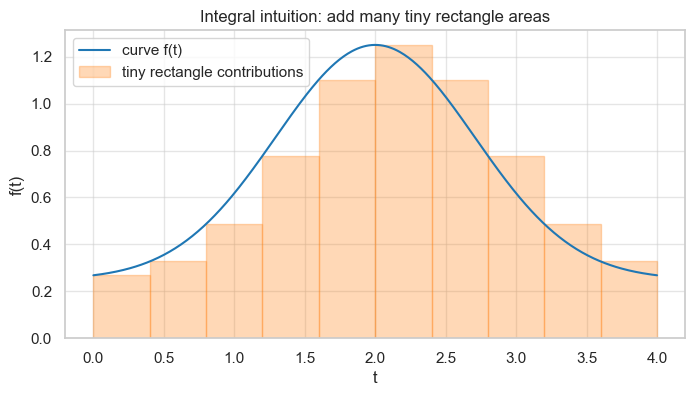

In [5]:
# Visual idea: an integral adds many tiny areas under a curve.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

x = np.linspace(0.0, 4.0, 400)
y = 0.25 + np.exp(-((x - 2.0) ** 2))

rectangle_left_edges = np.linspace(0.0, 3.6, 10)
rectangle_width = rectangle_left_edges[1] - rectangle_left_edges[0]
rectangle_heights = 0.25 + np.exp(-((rectangle_left_edges - 2.0) ** 2))

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(x=x, y=y, ax=ax, label="curve f(t)", color="tab:blue")
ax.bar(
    rectangle_left_edges,
    rectangle_heights,
    width=rectangle_width,
    align="edge",
    alpha=0.30,
    color="tab:orange",
    edgecolor="tab:orange",
    label="tiny rectangle contributions",
)
ax.set_title("Integral intuition: add many tiny rectangle areas")
ax.set_xlabel("t")
ax.set_ylabel("f(t)")
ax.legend()
plt.show()


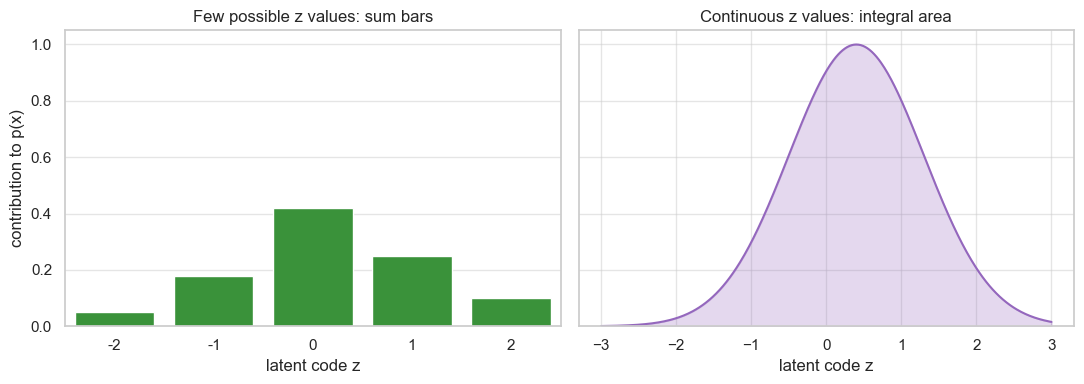

In [6]:
# Discrete sum vs continuous integral.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

discrete_z = np.array([-2, -1, 0, 1, 2])
discrete_contribution = np.array([0.05, 0.18, 0.42, 0.25, 0.10])

continuous_z = np.linspace(-3.0, 3.0, 400)
continuous_contribution = np.exp(-0.5 * ((continuous_z - 0.4) / 0.9) ** 2)
continuous_contribution /= continuous_contribution.max()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sns.barplot(x=discrete_z, y=discrete_contribution, ax=axes[0], color="tab:green")
axes[0].set_title("Few possible z values: sum bars")
axes[0].set_xlabel("latent code z")
axes[0].set_ylabel("contribution to p(x)")

sns.lineplot(x=continuous_z, y=continuous_contribution, ax=axes[1], color="tab:purple")
axes[1].fill_between(continuous_z, continuous_contribution, alpha=0.25, color="tab:purple")
axes[1].set_title("Continuous z values: integral area")
axes[1].set_xlabel("latent code z")

plt.tight_layout()
plt.show()


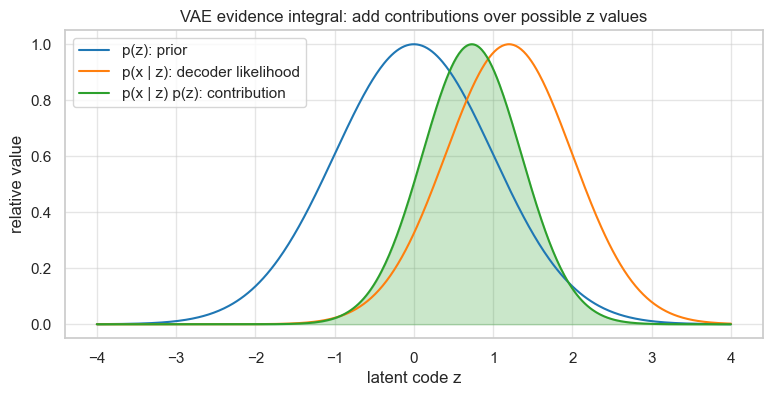

In [7]:
# VAE likelihood picture: prior times decoder likelihood gives each z contribution.

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

z = np.linspace(-4.0, 4.0, 500)
prior_p_z = np.exp(-0.5 * z**2)
prior_p_z /= prior_p_z.max()

# Toy decoder likelihood for one fixed image x: this image is most likely near z = 1.2.
decoder_likelihood = np.exp(-0.5 * ((z - 1.2) / 0.8) ** 2)
decoder_likelihood /= decoder_likelihood.max()

contribution = prior_p_z * decoder_likelihood
contribution /= contribution.max()

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(x=z, y=prior_p_z, ax=ax, label="p(z): prior", color="tab:blue")
sns.lineplot(x=z, y=decoder_likelihood, ax=ax, label="p(x | z): decoder likelihood", color="tab:orange")
sns.lineplot(x=z, y=contribution, ax=ax, label="p(x | z) p(z): contribution", color="tab:green")
ax.fill_between(z, contribution, alpha=0.25, color="tab:green")
ax.set_title("VAE evidence integral: add contributions over possible z values")
ax.set_xlabel("latent code z")
ax.set_ylabel("relative value")
ax.legend()
plt.show()


### Using the VAE integral like a sum

The VAE evidence formula is:

$$
p_\theta(x) = \int p_\theta(x \mid z)\,p(z)\,dz
$$

Read it first as a sum-like recipe:

```text
for every possible latent code z:
    contribution from this z = decoder score for x from z times prior plausibility of z
add all contributions
```

If there were only three possible latent codes, we could write an ordinary sum:

$$
p_\theta(x) \approx p_\theta(x \mid z_1)p(z_1) + p_\theta(x \mid z_2)p(z_2) + p_\theta(x \mid z_3)p(z_3)
$$

But $z$ is continuous, so there are not just three choices. The possible $z$ values form a smooth space. The integral is the continuous version of that sum.

Visual decoding of one contribution:

```text
p(z)             = is this z plausible before seeing the image?
p_theta(x | z)  = if we decode from this z, does it support image x?
product          = how much this z contributes to explaining x
dz               = a tiny slice of z-space
integral         = add those tiny contributions over all z
```

The product matters because a latent code should contribute a lot only when both parts are high:

| case | $p(z)$ | $p_\theta(x \mid z)$ | contribution |
| --- | ---: | ---: | --- |
| plausible $z$, decodes into $x$ well | high | high | large |
| plausible $z$, decodes into $x$ poorly | high | low | small |
| rare $z$, decodes into $x$ well | low | high | small |
| rare $z$, decodes into $x$ poorly | low | low | tiny |

Beginner translation:

```text
p_theta(x)
= total model support for image x
= add support from every possible hidden latent explanation z
```


### Evidence and the hard part

Some texts call the full likelihood of an image the **evidence**, written $p_\theta(x)$. Read it as:

```text
p(x) = the model's overall probability for this image x
```

Formula view:

$$
p_\theta(x) = \int p_\theta(x \mid z)\,p(z)\,dz
$$

Read the integral sign $\int$ as: add up the contribution from all possible latent codes $z$. The hard part is that many different latent codes `z` could decode into similar-looking images. To compute $p_\theta(x)$ directly, the model would need to consider all possible `z` values that might have produced `x`. That is too expensive to do exactly in a neural network.

This is why the encoder is useful. The encoder gives an approximate answer to:

```text
Given image x, which latent codes z are likely?
```

That approximate answer is the encoder distribution $q_\phi(z \mid x)$, described by `mu` and `logvar`.


## 10. ELBO intuition

Because direct $\log p_\theta(x)$ is hard, VAEs optimize a related objective called the **ELBO**, short for **Evidence Lower BOund**.

Beginner translation:

```text
ELBO = a trainable score for how well the VAE explains x
```

It is called a lower bound because it stays below the true $\log p_\theta(x)$, but improving the ELBO usually improves the model. The VAE can compute and optimize this lower-bound score even when the exact evidence is too hard.

Simple formula view:

$$
\log p_\theta(x)
\ge
\mathbb{E}_{q_\phi(z \mid x)}[\log p_\theta(x \mid z)]
-
D_{KL}\left(q_\phi(z \mid x)\,\|\,p(z)\right)
$$

Read it as:

```text
true image likelihood is at least:
reconstruction reward minus KL penalty
```

Training code usually minimizes losses instead of maximizing rewards, so we use **negative ELBO**:

$$
-\text{ELBO} = \mathcal{L}_{\text{recon}} + \mathcal{L}_{\text{KL}}
$$

That is the reason the practical notebook returns the sum of the two terms:

```python
return reconstruction_loss + kl_loss
```

High-level meaning:

- Reconstruction loss asks: can the decoder rebuild this image from the sampled latent code?
- KL loss asks: did the encoder keep the image's latent cloud near the simple prior cloud?
- Negative ELBO combines both goals into one trainable loss.


## 11. Mapping the math back to `loss_function()`

The practical notebook's loss function is a compact implementation of negative ELBO.

```python
reconstruction_loss = F.binary_cross_entropy(
    recon_x,
    x.view(-1, 784),
    reduction="sum",
)

kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

return reconstruction_loss + kl_loss
```

Line-by-line map:

| Code | Math idea | Plain meaning |
| --- | --- | --- |
| `recon_x` | $\hat{x}$ | decoder's rebuilt pixels |
| `x.view(-1, 784)` | $x$ | original image pixels flattened to match `recon_x` |
| `F.binary_cross_entropy(...)` | $\mathcal{L}_{\text{recon}}$ | pixel reconstruction penalty |
| `mu` | $\mu$ | center of the encoder's latent cloud |
| `logvar` | $\log \sigma^2$ | stored spread value for the latent cloud |
| `logvar.exp()` | $\sigma^2$ | variance recovered from log variance |
| `mu.pow(2)` | $\mu^2$ | penalty for moving the center away from 0 |
| `kl_loss` | $\mathcal{L}_{\text{KL}}$ | penalty for drifting away from $\mathcal{N}(0, I)$ |
| `return reconstruction_loss + kl_loss` | $-\text{ELBO}$ | rebuild well while keeping latent space sampleable |

Compact mental model:

$$
\boxed{\text{VAE loss} = \text{rebuild the image} + \text{organize the latent space}}
$$
